In [1]:
import nilearn as nl
import numpy as np
import matplotlib
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import openpyxl as xl

from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix
from nilearn.glm.first_level import FirstLevelModel
from nilearn.masking import compute_epi_mask, apply_mask, unmask
from nilearn.image import index_img, resample_to_img, math_img, mean_img, get_data
from nilearn.plotting import plot_stat_map, show
from nilearn import image, masking
from nilearn import plotting
from nilearn.datasets import load_mni152_brain_mask
from pandas import read_excel

from nilearn.glm.second_level import SecondLevelModel
from scipy.stats import norm

from nilearn.glm import threshold_stats_img

from nilearn.maskers import NiftiSpheresMasker
from nilearn.reporting import get_clusters_table

from atlasreader import create_output

The Python package you are importing, AtlasReader, is licensed under the
BSD-3 license; however, the atlases it uses are separately licensed under more
restrictive frameworks.
By using AtlasReader, you agree to abide by the license terms of the
individual atlases. Information on these terms can be found online at:
https://github.com/miykael/atlasreader/tree/master/atlasreader/data



In [2]:
#pip install atlasreader

## second level model SOCIAL STORY

In [3]:
contrastImg_dir = "../_results/processed_first_level_MAC_family/social/"

all_imgs = [
    os.path.join(contrastImg_dir, name) 
    for name in os.listdir(contrastImg_dir)
]


In [4]:
second_level_input = all_imgs


In [5]:
# create a design matrix for one sample t test, to be used as input for the second level model
design_matrix = pd.DataFrame(
    [1] * len(second_level_input),
    columns=["intercept"],
)

In [6]:
design_matrix

,intercept
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1


In [7]:
# set up group analysis for one sample t test on the contrast images
second_level_model = SecondLevelModel() 
second_level_model = second_level_model.fit(
    second_level_input,
    design_matrix=design_matrix,
)

In [8]:
# run one sample t test
z_map = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type="z_score",
) 

z_map.to_filename("SecondLevel_Social_zscore_macFamily.nii.gz")

#output_type{‘z_score’, ‘stat’, ‘p_value’, ‘effect_size’, ‘effect_variance’, ‘all’},

#### fdr correction

In [9]:


thresholded_map, threshold = threshold_stats_img(
    stat_img=z_map,  # or p_map
    alpha=0.05,
    height_control='fdr',  # or 'bonferroni'
    cluster_threshold=0,   # min cluster size in voxels
    two_sided=True
)
print(f"The p<.05 FDR-corrected threshold is z score of {threshold:.3g}")

The p<.05 FDR-corrected threshold is z score of 3.06


In [10]:
# save as brain image
thresholded_map.to_filename("threshold_"+f"{threshold:.3g}"+"_"+
                            "SecondLevel_social_fdrcorrect_macFamily.nii.gz")

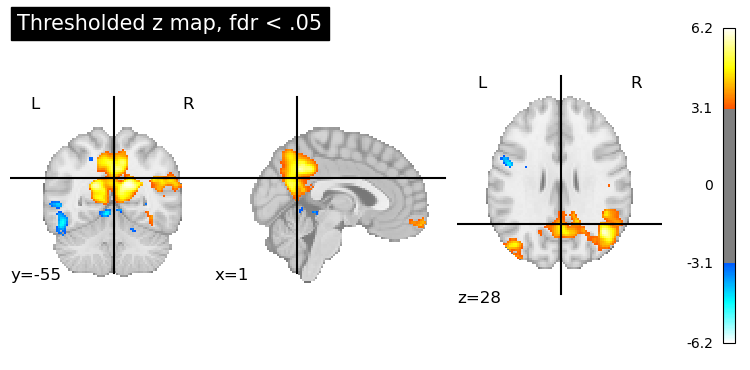

In [11]:
# quick visualization
plotting.plot_stat_map(
    thresholded_map,
    title="Thresholded z map, fdr < .05",
    threshold=threshold,
)

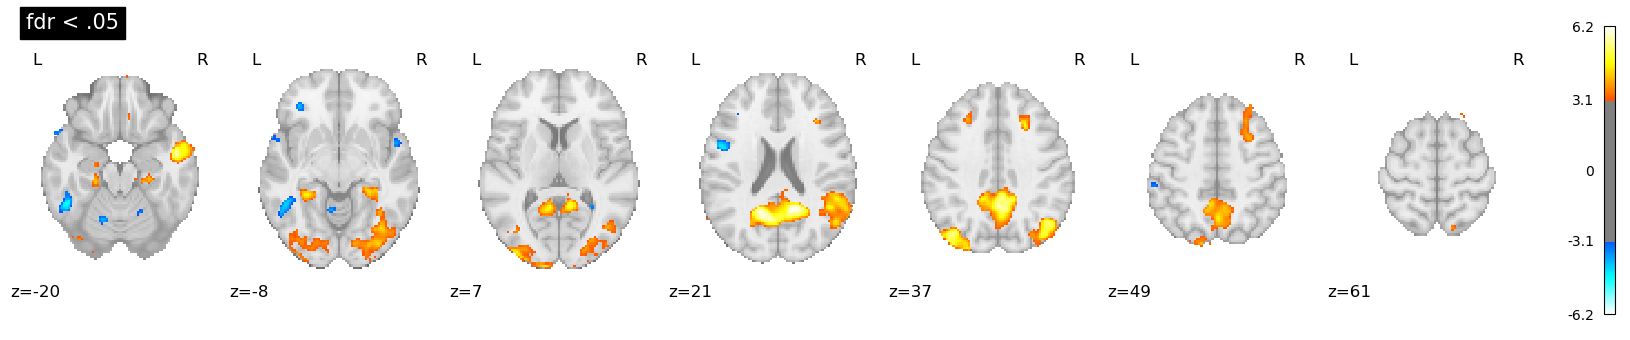

In [12]:
plotting.plot_stat_map(
    thresholded_map,
    threshold=threshold,
    display_mode="z",
    title="fdr < .05",
)


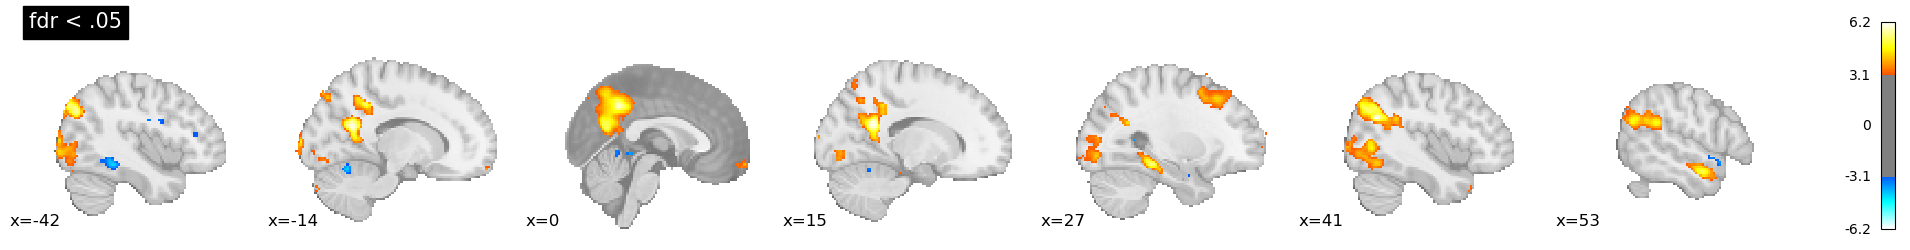

In [13]:
plotting.plot_stat_map(
    thresholded_map,
    threshold=threshold,
    display_mode="x",
    title="fdr < .05",
)

#### bonferroni correction

In [14]:
thresholded_map2, threshold2 = threshold_stats_img(
    z_map, alpha=0.05, height_control="bonferroni"
)
print(f"The p<.05 Bonferroni-corrected threshold is z score of {threshold2:.3g}")

The p<.05 Bonferroni-corrected threshold is z score of 5.22


In [15]:
# save as brain image
thresholded_map2.to_filename("threshold_"+f"{threshold2:.3g}"+"_"+
                             "SecondLevel_social_bonfcorrect_macFamily.nii.gz")

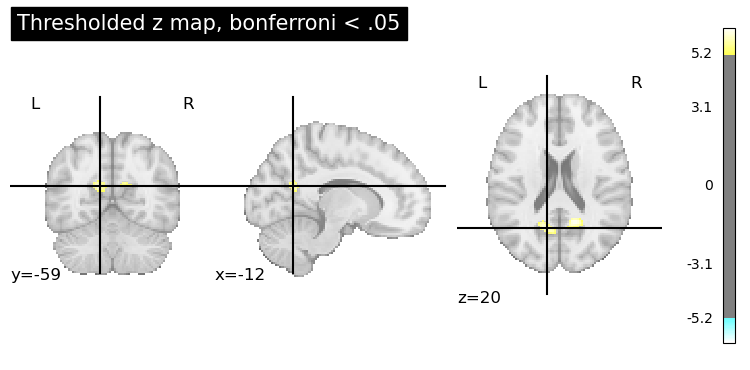

In [16]:
# quick visualization
plotting.plot_stat_map(
    thresholded_map2,
    title="Thresholded z map, bonferroni < .05",
    threshold=threshold2,
)

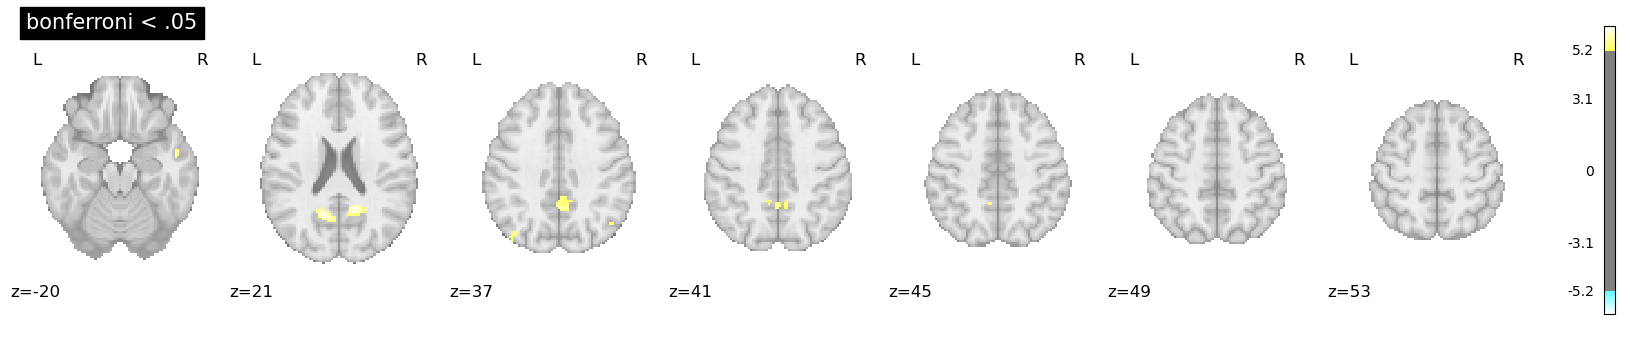

In [17]:
# quick visualization
plotting.plot_stat_map(
    thresholded_map2,
    title="bonferroni < .05",
    threshold=threshold2,
    display_mode = 'z'
)

#### tables

In [18]:
# table = get_clusters_table(
#     thresholded_map, stat_threshold=threshold, cluster_threshold=10
# )
# table.set_index("Cluster ID", drop=True)

In [19]:
# above table only has MNI coordinates, atlasreader has also anatomical labels (on fdr correction _results)

#create_output(thresholded_map, cluster_extent=0, direction = 'pos')

# Second Level Model PHYSICAL STORY

['./processed_first_level_MAC_family/physical/252_physical_macFamily.nii.gz', './processed_first_level_MAC_family/physical/225_physical_macFamily.nii.gz', './processed_first_level_MAC_family/physical/247_physical_macFamily.nii.gz', './processed_first_level_MAC_family/physical/230_physical_macFamily.nii.gz', './processed_first_level_MAC_family/physical/186_physical_macFamily.nii.gz', './processed_first_level_MAC_family/physical/216_physical_macFamily.nii.gz', './processed_first_level_MAC_family/physical/211_physical_macFamily.nii.gz', './processed_first_level_MAC_family/physical/248_physical_macFamily.nii.gz', './processed_first_level_MAC_family/physical/181_physical_macFamily.nii.gz', './processed_first_level_MAC_family/physical/219_physical_macFamily.nii.gz', './processed_first_level_MAC_family/physical/237_physical_macFamily.nii.gz', './processed_first_level_MAC_family/physical/240_physical_macFamily.nii.gz', './processed_first_level_MAC_family/physical/222_physical_macFamily.nii.gz'

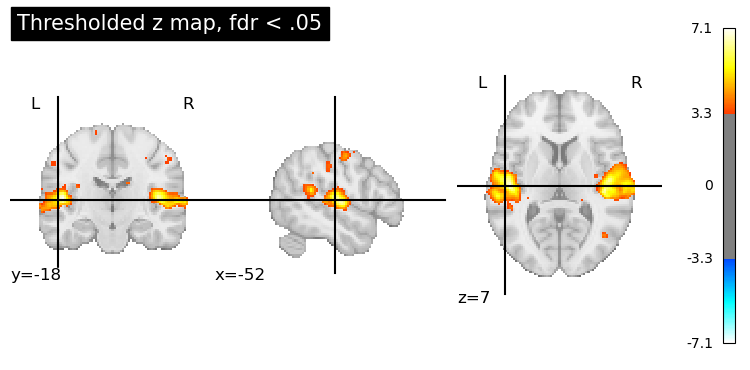

In [20]:
contrastImg_physical_dir = "../_results/processed_first_level_MAC_family/physical/"

all_imgs_physical = [
    os.path.join(contrastImg_physical_dir, name) 
    for name in os.listdir(contrastImg_physical_dir)
]

print(all_imgs_physical)

second_level_input_physical = all_imgs_physical

# create a design matrix for one sample t test, to be used as input for the second level model
design_matrix_physical = pd.DataFrame(
    [1] * len(second_level_input_physical),
    columns=["intercept"],
)

# set up group analysis for one sample t test on the contrast images
second_level_model = SecondLevelModel() 
second_level_model = second_level_model.fit(
    second_level_input_physical,
    design_matrix=design_matrix_physical,
)

# run one sample t test
z_map_physical = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type="z_score",
) 

z_map_physical.to_filename("SecondLevel_physical_zscore_macFamily.nii.gz")



thresholded_map_physical, threshold_physical = threshold_stats_img(
    stat_img=z_map_physical,  # or p_map
    alpha=0.05,
    height_control='fdr',  # or 'bonferroni'
    cluster_threshold=0,   # min cluster size in voxels
    two_sided=True
)
print(f"The p<.05 FDR-corrected threshold is z score of {threshold_physical:.3g}")

# save as brain image
thresholded_map_physical.to_filename("threshold_"+f"{threshold_physical:.3g}"+"_"+
                                     "SecondLevel_physical_fdrcorrect_macFamily.nii.gz")

# quick visualization
plotting.plot_stat_map(
    thresholded_map_physical,
    title="Thresholded z map, fdr < .05",
    threshold=threshold_physical,
)

## SECOND LEVEL MODEL: SOCIAL MINUS PHYSICAL

In [21]:
all_imgs_physical_sorted = sorted(all_imgs_physical)

In [22]:
all_imgs_social_sorted = sorted(all_imgs)

In [23]:
diff_imgs = [image.math_img("img1 - img2", img1=con1, img2=con2)
             for con1, con2 in zip(all_imgs_social_sorted, all_imgs_physical_sorted)]

In [24]:
design_matrix_socialMinusPhysical = pd.DataFrame([1] * len(diff_imgs), columns=["intercept"])


In [25]:
model = SecondLevelModel().fit(diff_imgs, design_matrix=design_matrix_socialMinusPhysical)
zmap_socialMinusPhysical = model.compute_contrast("intercept", output_type="z_score")


In [26]:
zmap_socialMinusPhysical.to_filename("SecondLevel_SocialMinusPhysical_zscore_macFamily.nii.gz")



thresholded_map_socialMinusPhysical, threshold_socialMinusPhysical = threshold_stats_img(
    stat_img=zmap_socialMinusPhysical,  # or p_map
    alpha=0.05,
    height_control='fdr',  # or 'bonferroni'
    cluster_threshold=0,   # min cluster size in voxels
    two_sided=True
)
print(f"The p<.05 FDR-corrected threshold is z score of {threshold_socialMinusPhysical:.3g}")

# save as brain image
thresholded_map_socialMinusPhysical.to_filename("threshold_"+f"{threshold_socialMinusPhysical:.3g}"+"_"+
                                                "SecondLevel_SocialMinusPhysical_fdrcorrect_macFamily.nii.gz")


The p<.05 FDR-corrected threshold is z score of 3.53


# Second level model, PHYSICAL MINUS SOCIAL

In [27]:
diff_imgs_2 = [image.math_img("img1 - img2", img1=con1, img2=con2)
             for con1, con2 in zip(all_imgs_physical_sorted, all_imgs_social_sorted)]

design_matrix_PhysicalMinusSocial = pd.DataFrame([1] * len(diff_imgs_2), columns=["intercept"])

model = SecondLevelModel().fit(diff_imgs_2, design_matrix=design_matrix_PhysicalMinusSocial)
zmap_PhysicalMinusSocial = model.compute_contrast("intercept", output_type="z_score")

zmap_PhysicalMinusSocial.to_filename("SecondLevel_PhysicalMinusSocial_zscore_macFamily.nii.gz")

thresholded_map_PhysicalMinusSocial, threshold_PhysicalMinusSocial = threshold_stats_img(
    stat_img=zmap_PhysicalMinusSocial,  # or p_map
    alpha=0.05,
    height_control='fdr',  # or 'bonferroni'
    cluster_threshold=0,   # min cluster size in voxels
    two_sided=True
)
print(f"The p<.05 FDR-corrected threshold is z score of {threshold_PhysicalMinusSocial:.3g}")

# save as brain image
thresholded_map_PhysicalMinusSocial.to_filename("threshold_"+f"{threshold_PhysicalMinusSocial:.3g}"+"_"+
                                                "SecondLevel_PhysicalMinusSocial_fdrcorrect_macFamily.nii.gz")


The p<.05 FDR-corrected threshold is z score of 3.53


## SECOND LEVEL MODEL COMPARING ACROSS GROUPS

In [28]:
# load group number of participants
GroupIndex = pd.read_csv("../text/Narratives participants.csv")

# split
GroupIndex[['GroupNumber', 'TaskOrder']] = GroupIndex['Notes'].str.split(',', n=1, expand=True)

GroupIndex['GroupNumber'] = GroupIndex['GroupNumber'].str.strip()
GroupIndex['TaskOrder'] = GroupIndex['TaskOrder'].str.strip()

In [29]:
design_matrix

,intercept
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1


In [30]:
design_matrix = pd.get_dummies(GroupIndex[['GroupNumber']])
design_matrix["intercept"] = 1

design_matrix = design_matrix.astype(int)

In [31]:
contrast_matrix = np.eye(len(design_matrix.columns))[:3]  
contrast_matrix

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.]])

In [32]:
second_level_model = SecondLevelModel().fit(
    second_level_input=second_level_input_physical,  
    design_matrix=design_matrix
)

z_map_ftest_physical_groupDifferences = second_level_model.compute_contrast(
    contrast_matrix,
    output_type="z_score"
)

z_map_ftest_physical_groupDifferences.to_filename("SecondLevel_ftest_physical_groupDifferences_zscore_macFamily.nii.gz")

thresholded_map_Physical_groupDiff, threshold_Physical_groupDiff = threshold_stats_img(
    stat_img=z_map_ftest_physical_groupDifferences,  # or p_map
    alpha=0.05,
    height_control='fdr',  # or 'bonferroni'
    cluster_threshold=0,   # min cluster size in voxels
    two_sided=True
)
print(f"The p<.05 FDR-corrected threshold is z score of {threshold_Physical_groupDiff:.3g}")

# save as brain image
thresholded_map_Physical_groupDiff.to_filename("threshold_"+f"{threshold_Physical_groupDiff:.3g}"+"_"+
                                                "SecondLevel_Physical_groupDiff_fdrcorrect_macFamily.nii.gz")


The p<.05 FDR-corrected threshold is z score of 3.45


In [33]:
# F test shows general group differences for shapesphysical story, now compute group3 over group1 and 2


contrast_vec = np.array([-0.5, -0.5, 1, 0], dtype=float).ravel()


In [34]:
z_map_group3_over_group1_2 = second_level_model.compute_contrast(
    contrast_vec,
    output_type="z_score"
)

z_map_group3_over_group1_2.to_filename("SecondLevel_physical_group3_over_group1_2_zscore_macFamily.nii.gz")

thresholded_map_Physical_group3vs1_2, threshold_Physical_group3vs1_2 = threshold_stats_img(
    stat_img=z_map_group3_over_group1_2,  # or p_map
    alpha=0.05,
    height_control='fdr',  # or 'bonferroni'
    cluster_threshold=0,   # min cluster size in voxels
    two_sided=True
)
print(f"The p<.05 FDR-corrected threshold is z score of {threshold_Physical_group3vs1_2:.3g}")

# save as brain image
thresholded_map_Physical_group3vs1_2.to_filename("threshold_"+f"{threshold_Physical_group3vs1_2:.3g}"+"_"+
                                                "SecondLevel_Physical_group3_over_group1_2_fdrcorrect_macFamily.nii.gz")


The p<.05 FDR-corrected threshold is z score of inf


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/nilearn/glm/thresholding.py:303: UserWarning: The given float value must not exceed 4.832628791020947. But, you have given threshold=inf.
  stat_img = threshold_img(


# Second level model WORDPEAK SOCIAL

In [35]:
contrastImg_wordpeak_social_dir = "../_results/processed_first_level_MAC_family/wordpeak_social/"

all_imgs_wordpeak_social = [
    os.path.join(contrastImg_wordpeak_social_dir, name) 
    for name in os.listdir(contrastImg_wordpeak_social_dir)
    if name.endswith(".nii.gz")
]

print(all_imgs_wordpeak_social)

second_level_input_wordpeak_social = all_imgs_wordpeak_social

# create a design matrix for one sample t test, to be used as input for the second level model
design_matrix_wordpeak_social = pd.DataFrame(
    [1] * len(second_level_input_wordpeak_social),
    columns=["intercept"],
)

# set up group analysis for one sample t test on the contrast images
second_level_model = SecondLevelModel() 
second_level_model = second_level_model.fit(
    second_level_input_wordpeak_social,
    design_matrix=design_matrix_wordpeak_social,
)

# run one sample t test
z_map_wordpeak_social = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type="z_score",
) 

z_map_wordpeak_social.to_filename("SecondLevel_wordpeak_social_zscore_macFamily.nii.gz")

thresholded_map_wordpeak_social, threshold_wordpeak_social = threshold_stats_img(
    stat_img=z_map_wordpeak_social,  # or p_map
    alpha=0.05,
    height_control='fdr',  # or 'bonferroni'
    cluster_threshold=0,   # min cluster size in voxels
    two_sided=True
)
print(f"The p<.05 FDR-corrected threshold is z score of {threshold_wordpeak_social:.3g}")

# save as brain image
thresholded_map_wordpeak_social.to_filename("threshold_"+f"{threshold_wordpeak_social:.3g}"+"_"+
                                     "SecondLevel_wordpeak_social_fdrcorrect_macFamily.nii.gz")

['./processed_first_level_MAC_family/wordpeak_social/181_social_macFamily_wordPeak.nii.gz', './processed_first_level_MAC_family/wordpeak_social/253_social_macFamily_wordPeak.nii.gz', './processed_first_level_MAC_family/wordpeak_social/215_social_macFamily_wordPeak.nii.gz', './processed_first_level_MAC_family/wordpeak_social/222_social_macFamily_wordPeak.nii.gz', './processed_first_level_MAC_family/wordpeak_social/248_social_macFamily_wordPeak.nii.gz', './processed_first_level_MAC_family/wordpeak_social/239_social_macFamily_wordPeak.nii.gz', './processed_first_level_MAC_family/wordpeak_social/211_social_macFamily_wordPeak.nii.gz', './processed_first_level_MAC_family/wordpeak_social/226_social_macFamily_wordPeak.nii.gz', './processed_first_level_MAC_family/wordpeak_social/095_social_macFamily_wordPeak.nii.gz', './processed_first_level_MAC_family/wordpeak_social/049_social_macFamily_wordPeak.nii.gz', './processed_first_level_MAC_family/wordpeak_social/231_social_macFamily_wordPeak.nii.gz'